We want to see how including doppler broadening affects the transmission spectra that we've calculated for the 3 and 4 level systems.  This should be possible by sampling many velocities from the Maxwell-Boltzmann probability distribution, calculating the transmission spectrum for each sample, and then averaging all of the spectra.  

My understanding is that this should effectively add in a detuning to the atomic levels in the Hamiltonian.  It shouldn't affect the cavity because the cavity isn't moving.  It also probably shouldn't be the same for both levels because $\Delta f = f_0(1 + \frac{v}{c}) - f_0 = \frac{v}{c}f_0$.  The mean speed is ~272 m/s, which means that $f_0$ gets multiplied by ~$10^{-6}$.  The initial frequencies are 385 THz for $|1\rangle$ and 625 THz for $|2\rangle$, which means that the shifted frequencies should be 100's of MHz.

## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg, optimize
import qutip as qu
import sympy as sym

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## 3 Levels

In [4]:
# Define parameters that we'll need for sampling
m = 85 * 1.67e-27   # mass of Rb 85 atom converted to kg
kb = 1.381e-23      # Boltzmann's constant in J/K
T = 300             # temperature in K
c = 3e8             # speed of light in m/s
f01 = 385e3         # frequency of |1> in GHz
f02 = 625e3         # frequency of |2> in GHz

In [5]:
# Define the standard deviation
σ = np.sqrt(kb * T / m)
v_mean = np.sqrt(8 * kb * T / (np.pi * m))

# Get Gaussian samples
np.random.seed(0)
v_samples = np.random.normal(loc=0, scale=σ, size=100)

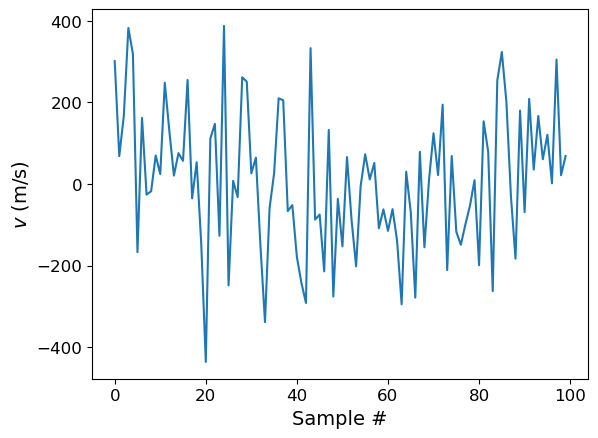

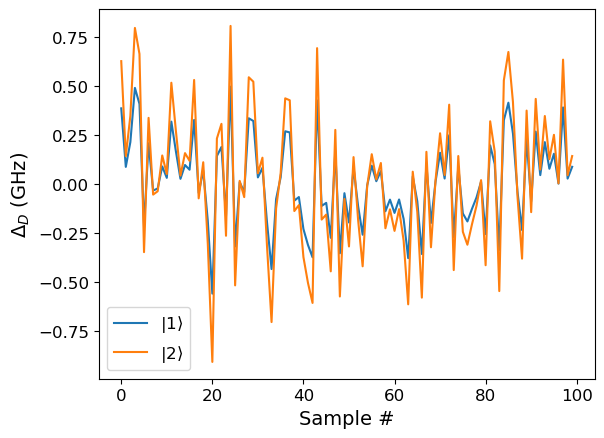

In [6]:
# Let's check what the bounds are on v_samples
plt.figure(1)
plt.plot(v_samples)
plt.xlabel("Sample #")
plt.ylabel("$v$ (m/s)")

# Now check the bounds on the doppler broadening
plt.figure(2)
plt.plot(v_samples / c * f01, label='$|1\\rangle$')
plt.plot(v_samples / c * f02, label='$|2\\rangle$')
plt.xlabel("Sample #")
plt.ylabel("$\\Delta_D$ (GHz)")
plt.legend()

In [7]:
# Define parameters for transmission spectrum calculation
δl = np.linspace(-25e-3, 25e-3, 100) # detuning parameter in GHz
g21 = 13e-3 / 2  # cavity coupling strength in GHz
g10 = 7e-3 / 2   # probe coupling strength in GHz
κ = 1.5e-3
γ21 = 1e-3
γ10 = 1e-3

In [8]:
# Check what this looks like compared to the previous
Ts = np.zeros(δl.shape[0], dtype=complex)
for i in range(δl.shape[0]):
    Hi = np.array([[δl[i] + 1j * κ, -g10, -g21],
                   [-g10, δl[i] + 1j * γ10, 0],
                   [-g21, 0, δl[i] + 1j * γ21]], dtype=complex)
    Ts[i] = np.abs(κ / 2) ** 2 * np.abs(np.array([1, 0, 0]).conj().T @ np.linalg.inv(Hi) @ np.array([1, 0, 0])) ** 2

/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


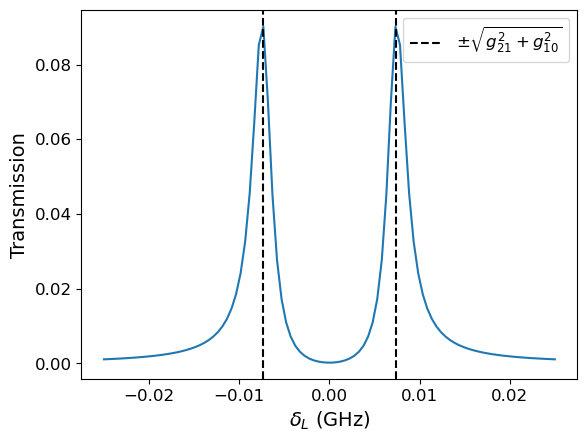

In [9]:
plt.plot(δl, Ts)
plt.xlabel("$\\delta_L$ (GHz)")
plt.ylabel("Transmission")
plt.axvline(x=-np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k', label='$\\pm\\sqrt{g_{21}^2 + g_{10}^2}$')
plt.axvline(x=np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k')
plt.legend()
#plt.savefig("transmission_vs_delta_L.png", format='png', dpi=300)

In [ ]:
# What do we get if we have the maximum bounds on the doppler broadening?
largest_Ts = np.zeros(δl.shape[0], dtype=complex)
for i in range(δl.shape[0]):
    Hi = np.array([[δl[i] + 1j * κ, -g10, 0],
                   [-g10, δl[i] - f01 / c * v_samples.max() + 1j * γ10, -g21],
                   [0, -g21, δl[i] - f02 / c * v_samples.max() + 1j * γ21]], dtype=complex)
    largest_Ts[i] = np.abs(κ / 2) ** 2 * np.abs(np.array([1, 0, 0]).conj().T @ np.linalg.inv(Hi) @ np.array([1, 0, 0])) ** 2

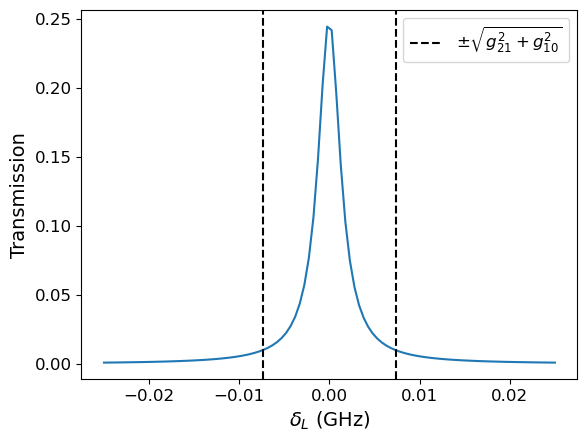

In [10]:
# Now plot
plt.plot(δl, largest_Ts)
plt.xlabel("$\\delta_L$ (GHz)")
plt.ylabel("Transmission")
plt.axvline(x=-np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k', label='$\\pm\\sqrt{g_{21}^2 + g_{10}^2}$')
plt.axvline(x=np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k')
plt.legend()

In [11]:
# Now repeat this for each sampled velocity
sampled_Ts = np.zeros((v_samples.shape[0], δl.shape[0]), dtype=complex)
for i in range(v_samples.shape[0]):
    for j in range(δl.shape[0]):
        H = np.array([[δl[j] + 1j * κ, g10, 0],
                      [g10, δl[j] + f01 / c * v_samples[i] + 1j * γ10, g21],
                      [0, g21, δl[j] - f02 / c * v_samples[i] + 1j * γ21]])
        sampled_Ts[i][j] = np.abs(κ / 2) ** 2 * np.abs(np.array([1, 0, 0]).conj().T @ np.linalg.inv(H) @ np.array([1, 0, 0])) ** 2

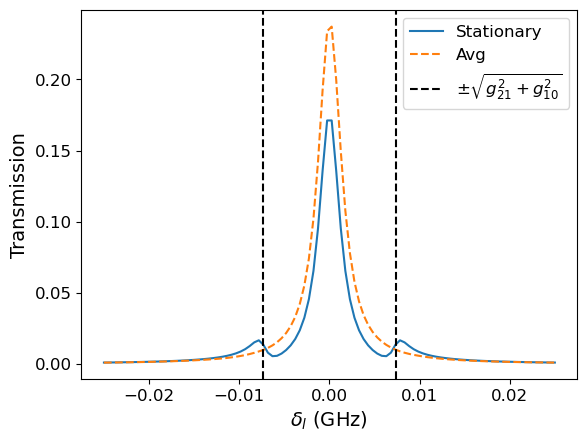

In [12]:
# Now plot the average transmission spectrum
plt.plot(δl, Ts, label='Stationary')
plt.plot(δl, np.mean(sampled_Ts, axis=0), '--', label='Avg')
plt.xlabel("$\\delta_l$ (GHz)")
plt.ylabel("Transmission")
plt.axvline(x=-np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k', label='$\\pm\\sqrt{g_{21}^2 + g_{10}^2}$')
plt.axvline(x=np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k')
plt.legend()
#plt.savefig("transmission_vs_deltaL_db_3lvl.png", format='png', dpi=300)

In [13]:
single_Ts = np.zeros(δl.shape[0], dtype=complex)
for j in range(δl.shape[0]):
    H = np.array([[δl[j] + 1j * κ, g10, 0],
                  [g10, δl[j] + 500e-3 + 1j * γ10, g21],
                  [0, g21, δl[j] + 1000e-3 + 1j * γ21]])
    single_Ts[j] = np.abs(κ / 2) ** 2 * np.abs(np.array([1, 0, 0]).conj().T @ np.linalg.inv(H) @ np.array([1, 0, 0])) ** 2

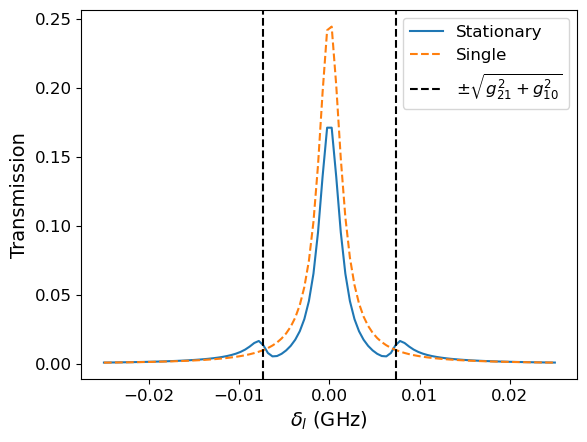

In [14]:
# Now plot the single velocity class transmission spectrum
plt.plot(δl, Ts, label='Stationary')
plt.plot(δl, single_Ts, '--', label='Single')
plt.xlabel("$\\delta_l$ (GHz)")
plt.ylabel("Transmission")
plt.axvline(x=-np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k', label='$\\pm\\sqrt{g_{21}^2 + g_{10}^2}$')
plt.axvline(x=np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k')
plt.legend()

Kevin suggested that it might be more useful to consider individual velocities instead of just the average.  We can do this by selecting the doppler shift we want to see because we don't actually care about the velocity.

In [15]:
# Define the Doppler shifts we'll be using
ΔD1 = np.array([5, 10, 100]) * 1e-3
ΔD2 = f02 / f01 * ΔD1

In [16]:
velocity_class_Ts = np.zeros((ΔD1.shape[0], δl.shape[0]), dtype=complex)
for i in range(ΔD1.shape[0]):
    for j in range(δl.shape[0]):
        Hij = np.array([[δl[j] + 1j * κ, g10, 0],
                        [g10, δl[j] + ΔD1[i] + 1j * γ10, g21],
                        [0, g21, δl[j] + ΔD2[i] + 1j * γ21]])
        velocity_class_Ts[i][j] = np.abs(κ / 2) ** 2 * np.abs(np.array([1, 0, 0]).conj().T @ np.linalg.inv(Hij) @ np.array([1, 0, 0])) ** 2

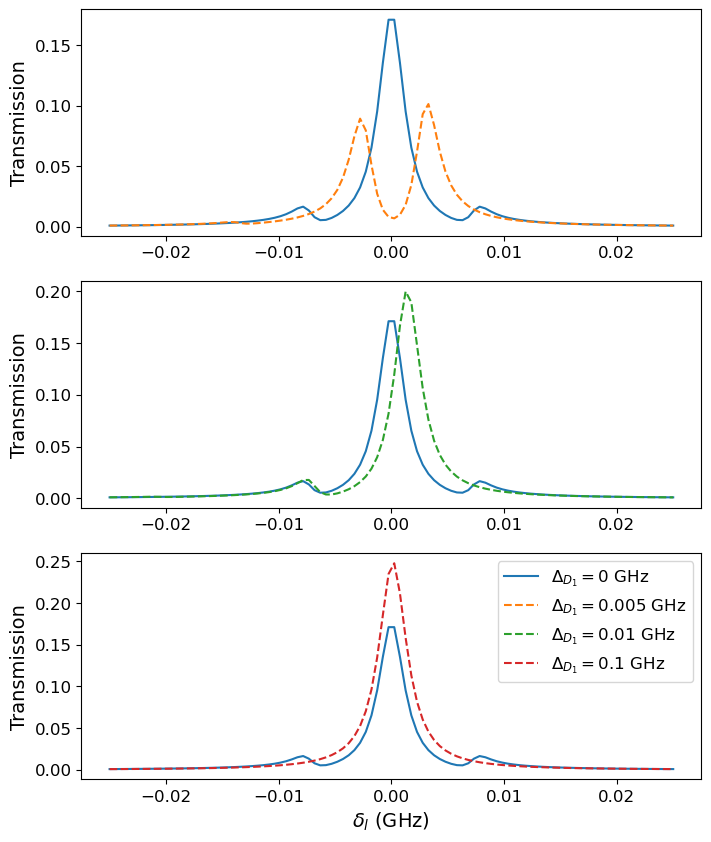

In [17]:
# Now plot the results
colors=['tab:orange', 'tab:green', 'tab:red']
fig = plt.figure(1, figsize=(8, 10))
ax = fig.subplots(3, 1)
ax[0].plot(δl, Ts, label="$\\Delta_{D_1}=0$ GHz")
for i in range(ΔD1.shape[0]):
    if i != 0:
        ax[i].plot(δl, Ts)
    ax[i].plot(δl, velocity_class_Ts[i], '--', color=colors[i], label="$\\Delta_{D_1}=" + str(ΔD1[i]) + "$ GHz")
    ax[i].set_ylabel("Transmission")
ax[2].set_xlabel("$\\delta_l$ (GHz)")
#plt.axvline(x=-np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k', label='$\\pm\\sqrt{g_{21}^2 + g_{10}^2}$')
#plt.axvline(x=np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k')
line_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(l, []) for l in zip(*line_labels)]
ax[2].legend(lines, labels)
#plt.savefig("T_vs_deltaL_spec_vel_classes_3lvl.png", format='png', dpi=300)

## 4 Levels
We can use the same velocity samples as before for now.  We will need to define the new frequency term though.

In [30]:
# Define frequency for the new level
f03 = 10   # frequency of |3> in GHz

In [59]:
δl = np.linspace(-25e-3, 25e-3, 1000) # detuning parameter in GHz
g32 = 0.1e-3 / 2  # cavity coupling strength in GHz
g21 = 13e-3 / 2  # probe 1 coupling strength in GHz
g10 = 7e-3 / 2   # probe 2 coupling strength in GHz
κ = 2e-3
γ32 = 0.1e-3
γ21 = 0.1e-3
γ10 = 0.1e-3

In [32]:
# Calculate the eigenvalues for later use
λ1 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 - 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ0 = -λ1
λ3 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 + 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ2 = -λ3

In [40]:
λ1, λ0

(np.float64(2.370456967231152e-05), np.float64(-2.370456967231152e-05))

In [41]:
λ3, λ2

(np.float64(0.007382542793196437), np.float64(-0.007382542793196437))

In [64]:
# Calculate v=0 case for comparison
Ts = np.zeros(δl.shape[0], dtype=complex)
for i in range(δl.shape[0]):
    Hi = np.array([[δl[i] + 1j * κ, g10, 0, 0],
                   [g10, δl[i] + 1j * γ10, g21, 0],
                   [0, g21, δl[i] + 1j * γ21, g32],
                   [0, 0, g32, δl[i] + 1j * γ32]], dtype=complex)
    Ts[i] = np.abs(κ / 2) ** 2 * np.abs(np.array([1, 0, 0, 0]).conj().T @ np.linalg.inv(Hi) @ np.array([1, 0, 0, 0])) ** 2

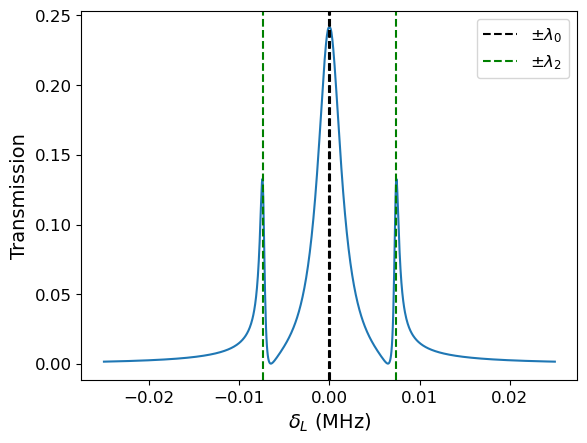

In [65]:
# Plot
plt.plot(δl, Ts)
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.axvline(x=λ0, linestyle='--', color='k', label='$\\pm\\lambda_0$')
plt.axvline(x=λ1, linestyle='--', color='k')
plt.axvline(x=λ2, linestyle='--', color='g', label='$\\pm\\lambda_2$')
plt.axvline(x=λ3, linestyle='--', color='g')
plt.legend()

In [35]:
# Calculate the transmission spectrum for each velocity
sampled_Ts = np.zeros((v_samples.shape[0], δl.shape[0]), dtype=complex)
for i in range(v_samples.shape[0]):
    for j in range(δl.shape[0]):
        H = np.array([[δl[j] + 1j * κ, g10, 0, 0],
                      [g10, δl[j] - f01 / c * v_samples[i] + 1j * γ10, g21, 0],
                      [0, g21, δl[j] - f02 / c * v_samples[i] + 1j * γ21, g32],
                      [0, 0, g32, δl[j] + 1j * γ32]], dtype=complex)
        sampled_Ts[i][j] = np.abs(κ / 2) ** 2 * np.abs(np.array([1, 0, 0, 0]).conj().T @ np.linalg.inv(H) @ np.array([1, 0, 0, 0])) ** 2

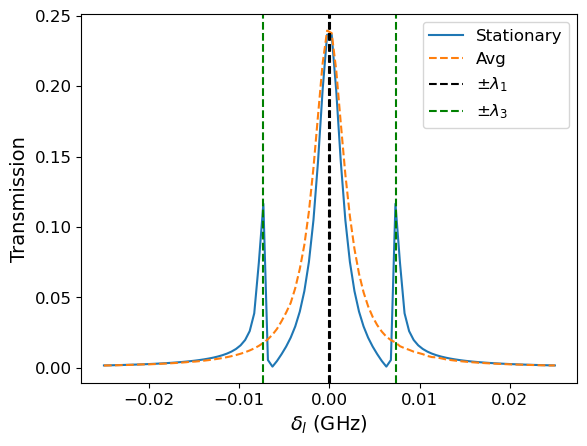

In [36]:
# Now plot the average transmission spectrum
plt.plot(δl, Ts, label='Stationary')
plt.plot(δl, np.mean(sampled_Ts, axis=0), '--', label='Avg')
plt.xlabel("$\\delta_l$ (GHz)")
plt.ylabel("Transmission")
plt.axvline(x=λ1, linestyle='--', color='k', label='$\\pm\\lambda_1$')
plt.axvline(x=λ0, linestyle='--', color='k')
plt.axvline(x=λ3, linestyle='--', color='g', label='$\\pm\\lambda_3$')
plt.axvline(x=λ2, linestyle='--', color='g')
plt.legend()
#plt.savefig("transmission_vs_deltaL_db_4lvl.png", format='png', dpi=300)

Now look at several defined velocity classes to see what changes.  In this case, $\Delta_{D_3} \ll \Delta_{D_1}, \Delta_{D_2}$, so we can neglect its Doppler broadening. 

In [44]:
# Define the Doppler shifts we'll be using
ΔD1 = np.array([5, 10, 100]) * 1e-3
ΔD2 = f02 / f01 * ΔD1

In [52]:
velocity_class_Ts = np.zeros((ΔD1.shape[0], δl.shape[0]), dtype=complex)
for i in range(ΔD1.shape[0]):
    for j in range(δl.shape[0]):
        Hij = np.array([[δl[j] + 1j * κ, g10, 0, 0],
                        [g10, δl[j] + ΔD1[i] + 1j * γ10, g21, 0],
                        [0, g21, δl[j] + ΔD2[i] + 1j * γ21, g32],
                        [0, 0, g32, δl[j] + 1j * γ32]])
        velocity_class_Ts[i][j] = np.abs(κ / 2) ** 2 * np.abs(np.array([1, 0, 0, 0]).conj().T @ np.linalg.inv(Hij) @ np.array([1, 0, 0, 0])) ** 2

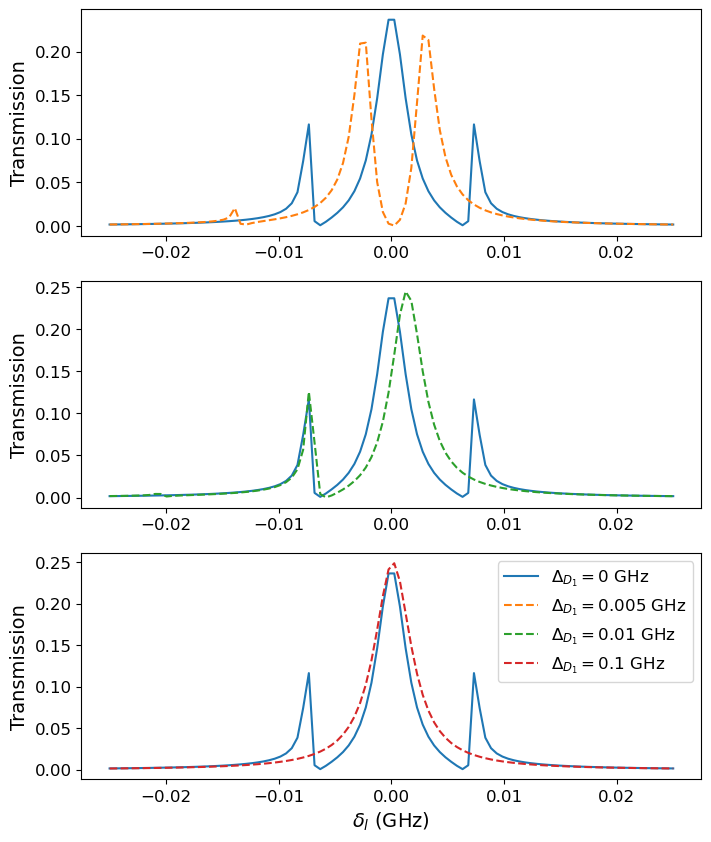

In [39]:
# Now plot the results
colors=['tab:orange', 'tab:green', 'tab:red']
fig = plt.figure(1, figsize=(8, 10))
ax = fig.subplots(3, 1)
ax[0].plot(δl, Ts, label="$\\Delta_{D_1}=0$ GHz")
for i in range(ΔD1.shape[0]):
    if i != 0:
        ax[i].plot(δl, Ts)
    ax[i].plot(δl, velocity_class_Ts[i], '--', color=colors[i], label="$\\Delta_{D_1}=" + str(ΔD1[i]) + "$ GHz")
    ax[i].set_ylabel("Transmission")
ax[2].set_xlabel("$\\delta_l$ (GHz)")
#plt.axvline(x=-np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k', label='$\\pm\\sqrt{g_{21}^2 + g_{10}^2}$')
#plt.axvline(x=np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k')
line_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(l, []) for l in zip(*line_labels)]
ax[2].legend(lines, labels)
#plt.savefig("T_vs_deltaL_spec_vel_classes_4lvl.png", format='png', dpi=300)

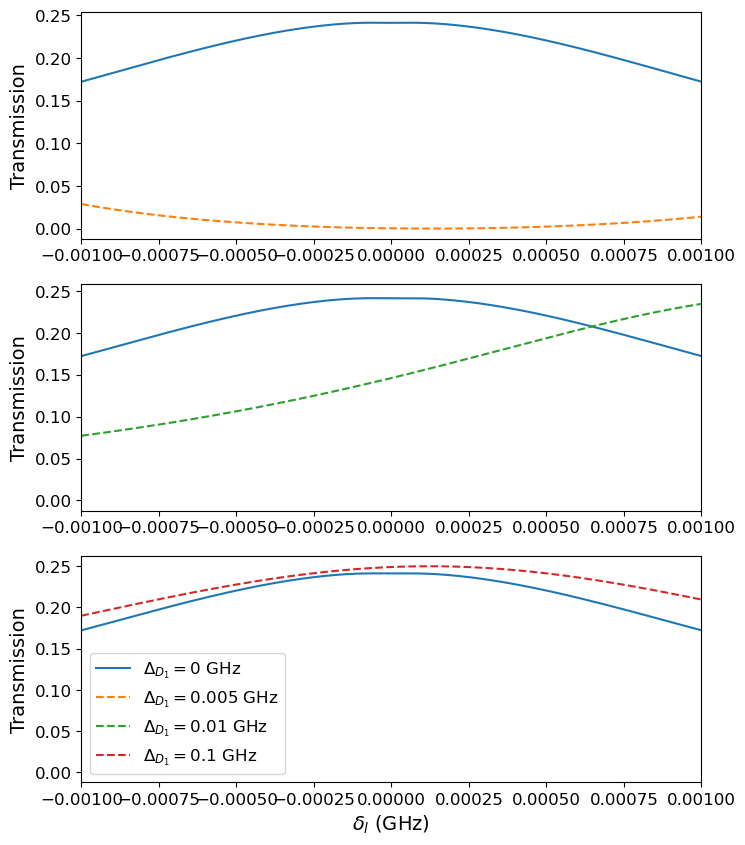

In [57]:
colors=['tab:orange', 'tab:green', 'tab:red']
fig = plt.figure(1, figsize=(8, 10))
ax = fig.subplots(3, 1)
ax[0].plot(δl, Ts, label="$\\Delta_{D_1}=0$ GHz")
for i in range(ΔD1.shape[0]):
    if i != 0:
        ax[i].plot(δl, Ts)
    ax[i].plot(δl, velocity_class_Ts[i], '--', color=colors[i], label="$\\Delta_{D_1}=" + str(ΔD1[i]) + "$ GHz")
    ax[i].set_ylabel("Transmission")
    ax[i].set_xlim([-1e-3, 1e-3])
ax[2].set_xlabel("$\\delta_l$ (GHz)")
#plt.axvline(x=-np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k', label='$\\pm\\sqrt{g_{21}^2 + g_{10}^2}$')
#plt.axvline(x=np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k')
line_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(l, []) for l in zip(*line_labels)]
ax[2].legend(lines, labels)

In [55]:
δl[0] - δl[1]

np.float64(-5.00005000049486e-07)